# Fase 2 — Análisis Exploratorio de Datos (EDA)

**Objetivo:** Reproducir y expandir las validaciones del paper original utilizando el dataset limpio.
Buscaremos responder visual y estadísticamente a:
1. ¿Cómo difiere el perfil de tráfico entre días secos y lluviosos?
2. ¿Qué impacto tiene la intensidad de la precipitación?
3. Análisis de evento: ¿Cómo evoluciona el tráfico antes, durante y después de la lluvia en una arteria principal?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

DATA_FILE = Path("../output/madrid_analytical_dataset.parquet")

# Configuración visual para gráficos académicos (estilo APA/Paper)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')

# Crear carpeta para guardar los gráficos de la memoria
Path("../output/figures").mkdir(parents=True, exist_ok=True)

print("Cargando dataset analítico...")
df = pd.read_parquet(DATA_FILE)

# Optimización de memoria (Pro-tip aplicado)
for col in ["fclass", "road", "city_code", "rain_intensity"]:
    df[col] = df[col].astype("category")

print(f"Dataset cargado. Shape: {df.shape}")

Cargando dataset analítico...
Dataset cargado. Shape: (5065890, 23)


# Perfil horario

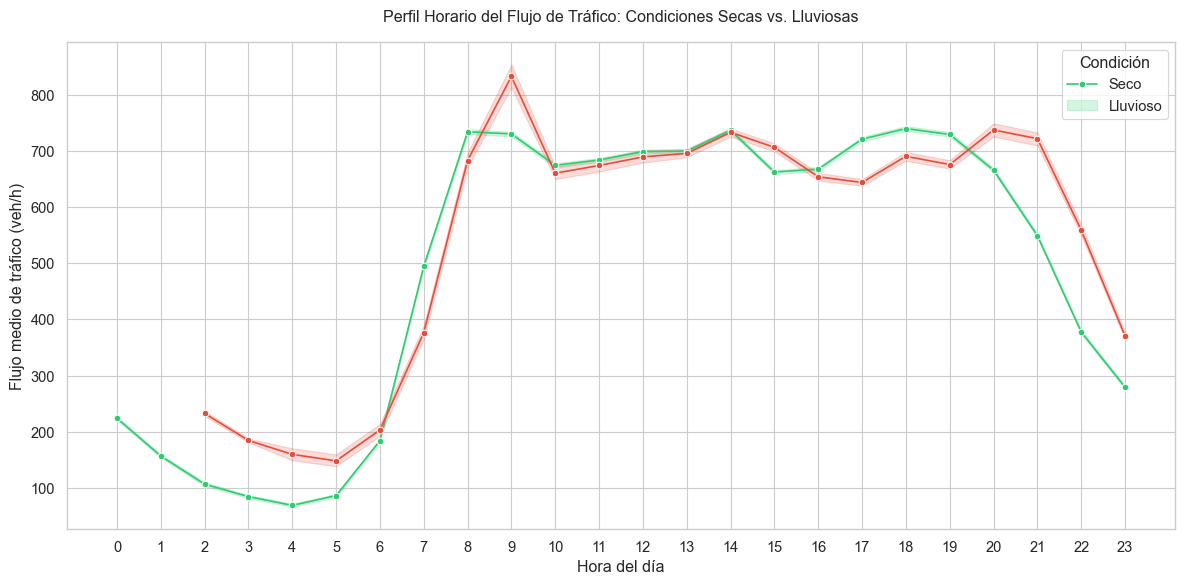

Flujo medio (Seco)    : 475.94 veh/h
Flujo medio (Lluvioso): 580.01 veh/h
Impacto global medio  : 21.87%


In [3]:
# 1. Perfil horario del tráfico: Días Secos vs Días Lluviosos
plt.figure(figsize=(12, 6))

# Usamos lineplot con el estimador de la media y el intervalo de confianza (95%)
sns.lineplot(
    data=df, 
    x="hour", 
    y="flow", 
    hue="is_rainy", 
    palette={0: "#2ecc71", 1: "#e74c3c"}, # Verde para seco, Rojo para lluvia
    marker="o",
    errorbar=("ci", 95)
)

plt.title("Perfil Horario del Flujo de Tráfico: Condiciones Secas vs. Lluviosas", pad=15)
plt.xlabel("Hora del día")
plt.ylabel("Flujo medio de tráfico (veh/h)")
plt.xticks(range(0, 24))
plt.legend(title="Condición", labels=["Seco", "Lluvioso"])

plt.tight_layout()
plt.savefig("../output/figures/1_perfil_horario_lluvia.png", dpi=300)
plt.show()

# Cuantificación para la Memoria
flujo_seco = df[df["is_rainy"] == 0]["flow"].mean()
flujo_lluvia = df[df["is_rainy"] == 1]["flow"].mean()
variacion = ((flujo_lluvia - flujo_seco) / flujo_seco) * 100

print(f"Flujo medio (Seco)    : {flujo_seco:.2f} veh/h")
print(f"Flujo medio (Lluvioso): {flujo_lluvia:.2f} veh/h")
print(f"Impacto global medio  : {variacion:.2f}%")

# 2 - Impacto por Intensidad de Precipitación

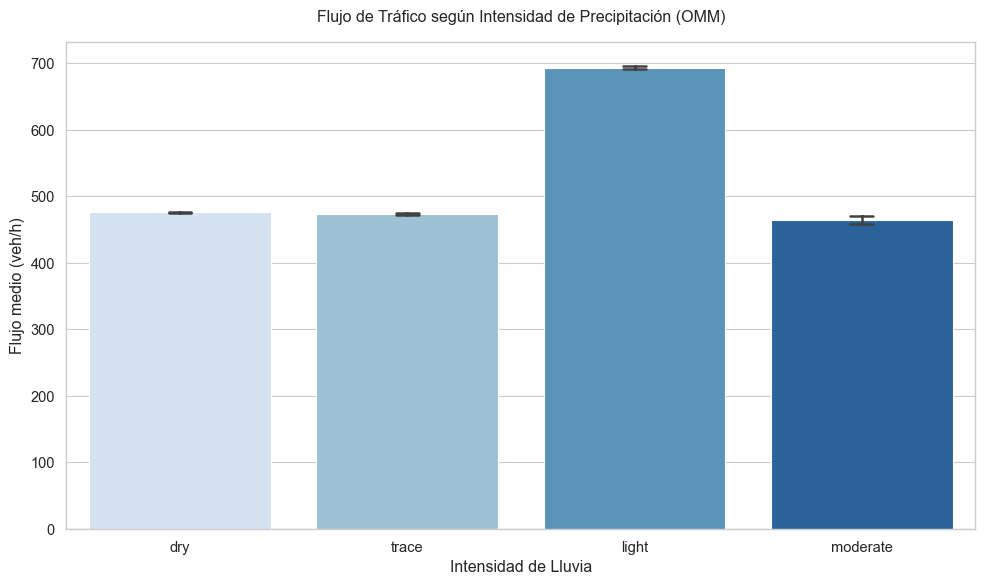

=== Resumen Estadístico por Intensidad ===
rain_intensity   mean   count  pct_change_vs_dry
           dry 476.20 3249798               0.00
         trace 473.83 1481654              -0.50
         light 693.51  307679              45.64
      moderate 464.98   26759              -2.36


In [4]:
# 2. Impacto según la intensidad de la lluvia
plt.figure(figsize=(10, 6))

# Filtramos los 'dry' para ver solo la progresión de la lluvia, 
# o los dejamos para tener la base. Dejémoslo completo.
sns.barplot(
    data=df, 
    x="rain_intensity", 
    y="flow", 
    palette="Blues",
    order=["dry", "trace", "light", "moderate"],
    errorbar=("ci", 95),
    capsize=0.1
)

plt.title("Flujo de Tráfico según Intensidad de Precipitación (OMM)", pad=15)
plt.xlabel("Intensidad de Lluvia")
plt.ylabel("Flujo medio (veh/h)")

plt.tight_layout()
plt.savefig("../output/figures/2_impacto_intensidad.png", dpi=300)
plt.show()

# Tabla de resumen estadístico para la Memoria
resumen_intensidad = df.groupby("rain_intensity")["flow"].agg(["mean", "count"]).reset_index()
resumen_intensidad["pct_change_vs_dry"] = (
    (resumen_intensidad["mean"] - resumen_intensidad.loc[0, "mean"]) 
    / resumen_intensidad.loc[0, "mean"] * 100
)
print("=== Resumen Estadístico por Intensidad ===")
print(resumen_intensidad.round(2).to_string(index=False))

# 3 - Caso de Estudio (Antes, Durante y Después)

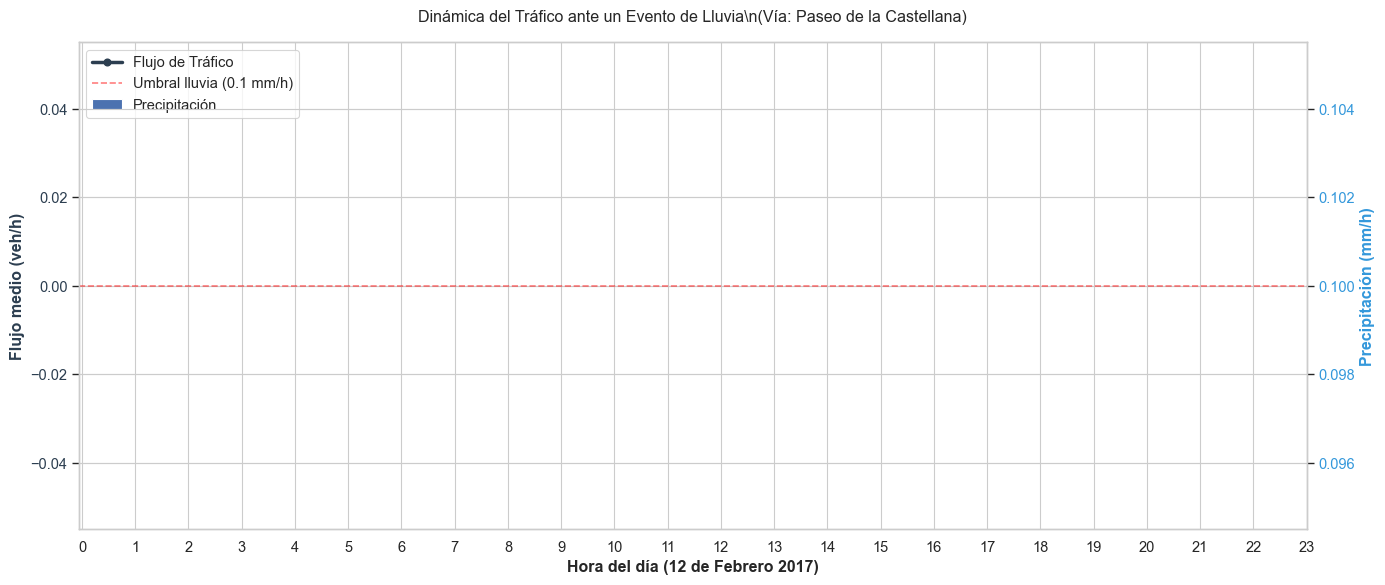

In [6]:
# 3. Análisis de Evento Temporal Temporal (Micro-nivel)

# Seleccionamos una vía principal conocida
target_road = "Paseo de la Castellana"

# Buscamos un día específico con un buen evento de lluvia (ej. 2017-02-12 o 2016-10-22)
# Tras inspeccionar los datos, el 12 de febrero de 2017 tiene buena lluvia.
target_date = "2017-02-12"

# Filtramos los datos
event_df = df[
    (df["road"] == target_road) & 
    (df["datetime"].dt.date == pd.to_datetime(target_date).date())
].copy()

# Como hay varios sensores en la misma calle, agrupamos por hora para tener una señal limpia
event_hourly = event_df.groupby("datetime_hour").agg({
    "flow": "mean",
    "precip_mm_h": "first" # La lluvia es la misma para esa hora
}).reset_index()

# Creación del gráfico con doble eje Y
fig, ax1 = plt.subplots(figsize=(14, 6))

# Eje principal (Tráfico)
color_trafico = '#2c3e50'
ax1.plot(event_hourly["datetime_hour"].dt.hour, event_hourly["flow"], 
         color=color_trafico, linewidth=2.5, marker='o', label="Flujo de Tráfico")
ax1.set_xlabel("Hora del día (12 de Febrero 2017)", fontweight='bold')
ax1.set_ylabel("Flujo medio (veh/h)", color=color_trafico, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_trafico)
ax1.set_xticks(range(0, 24))

# Eje secundario (Lluvia)
ax2 = ax1.twinx()
color_lluvia = '#3498db'
ax2.bar(event_hourly["datetime_hour"].dt.hour, event_hourly["precip_mm_h"], 
        color=color_lluvia, alpha=0.4, width=1, label="Precipitación")
ax2.set_ylabel("Precipitación (mm/h)", color=color_lluvia, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_lluvia)

# Añadir un umbral visual para donde consideramos que empieza a llover
ax2.axhline(0.1, color='red', linestyle='--', alpha=0.5, label="Umbral lluvia (0.1 mm/h)")

plt.title(f"Dinámica del Tráfico ante un Evento de Lluvia\\n(Vía: {target_road})", pad=15)

# Unificar leyendas
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.savefig("../output/figures/3_evento_temporal.png", dpi=300)
plt.show()